# MultiSceneDatasetV4 + Stage5_4 Demo Use Cases

本 notebook 对应配置：`configs/minimal_streetforward_stage5_4_production_multi_scene_v8.yaml`

包含 3 个演示：
1. 指定 `scene/segment/frame/camera` 读取图像，并显示深度热力图
2. BG 点云：默认用 `PLYViewer` 浏览器查看（与 `MultiSceneDataset_Demo` 一致）；可选 `nerfview`+gsplat 实时渲染（需在 cell 内切换）
3. 按 stage5_4 配置初始化 3DGS 场景，并用 nerfview 演示（白色背景）

In [6]:
import os

# Set before NumPy / Torch import (restart kernel + rerun this cell if you change this).
# Nerfview renders from a worker thread; oversubscribed BLAS/OpenMP + CUDA can crash the kernel.
for _env_key in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(_env_key, "1")

import sys
import argparse
from pathlib import Path

import numpy as np
import torch
import matplotlib

# Compatibility shim for older matplotlib_inline expecting rcParams._get.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt
import viser
import nerfview

from gsplat.rendering import rasterization
from omegaconf import OmegaConf

# 0) 项目根目录与 import 路径（对齐 MultiSceneDataset_Demo：优先相对 cwd 解析）
_cwd = Path.cwd().resolve()
if (_cwd / "datasets").is_dir():
    project_root = _cwd
elif (_cwd.parent / "datasets").is_dir():
    project_root = _cwd.parent
else:
    project_root = Path("/root/drivestudio-coding")
project_root = str(project_root)
sys.path.insert(0, project_root)
os.environ["PYTHONPATH"] = project_root

from datasets.multi_scene_dataset_v4 import BatchRequestV4
from tools.train_minimal_streetforward_stage1_1 import setup
from tools.train_minimal_streetforward_stage4_3_v8_common import build_multi_scene_dataset_v4_for_demo
from tools.streetforward_stage5_demo_scheduler import build_stage5_demo_scheduler_from_cfg
from tools.streetforward_stage5_demo_controller import Stage5DemoController
from tools.streetforward_stage5_viewer import StreetForwardStage5Viewer
from models.streetforward.minimal_trainer_stage5_4 import MinimalStreetForwardStage5_4
from models.streetforward.minimal_trainer_stage5_4_production import MinimalStreetForwardStage5_4_Production

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires CUDA (gsplat rasterization is CUDA-only).")

device = torch.device("cuda")


def _nerfview_img_wh(tab_or_wh):
    """Resolve (W, H) from nerfview RenderTabState (new API) or legacy (w, h) tuple."""
    if hasattr(tab_or_wh, "viewer_width"):
        w, h = int(tab_or_wh.viewer_width), int(tab_or_wh.viewer_height)
    else:
        w, h = tab_or_wh
        w, h = int(w), int(h)
    w = max(1, min(w, 8192))
    h = max(1, min(h, 8192))
    return w, h


print("device:", device)

device: cuda


In [7]:
# 通用参数（你可以改这里）
config_file = "/root/drivestudio-coding/configs/minimal_streetforward_stage5_4_production_multi_scene_v8.yaml"

scene_id = 196
segment_id = 3
frame_idx = 92
camera_id = 0

# nerfview 端口（避免冲突）
bg_viewer_port = 8099
stage5_viewer_port = 8100
viewer_host = "0.0.0.0"

# 构造 cfg
args = argparse.Namespace(
    config_file=config_file,
    output_root="outputs",
    project="minimal_sf",
    run_name="stage5_4_notebook_demo",
    opts=[],
)
cfg = setup(args)

# demo 场景下禁用 preload + scheduler_v8
if cfg.get("scheduler_v8") is not None:
    cfg.scheduler_v8.enable = False
if cfg.get("data") is None:
    cfg.data = {}
if cfg.data.get("preload") is None:
    cfg.data.preload = {}
cfg.data.preload.enable = False

if cfg.get("demo") is None:
    cfg.demo = {}
if cfg.demo.get("scheduler") is None:
    cfg.demo.scheduler = {}

cfg.demo.scheduler.initial_scene_id = int(scene_id)
cfg.demo.scheduler.initial_segment_id = int(segment_id)

# 可选：为了更快初始化，只保留一个 scene
cfg.data.train_scene_ids = [int(scene_id)]
cfg.data.eval_scene_ids = []

dataset = build_multi_scene_dataset_v4_for_demo(cfg, device)
dataset.initialize()

print("dataset initialized")
print("train scenes:", dataset.list_training_scene_ids()[:10])
print("segments in scene", scene_id, ":", dataset.list_segment_ids(scene_id)[:20])

I20260508 12:33:56 tools.train_minimal_streetforward_stage1_1 train_minimal_streetforward_stage1_1.py:572] Config:
output_name: experiment002_60w_40w_12block_base_on_001
data:
  data_root: /root/autodl-tmp/nuScenes/
  dataset: nuscenes
  start_timestep: 0
  end_timestep: -1
  preload_device: cpu
  sky_mask_semantics: one_is_sky
  train_scene_ids:
  - 0
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6
  - 7
  - 8
  - 9
  - 14
  - 16
  - 24
  - 32
  - 40
  - 99
  - 107
  - 115
  - 123
  - 131
  - 139
  - 147
  - 155
  - 163
  - 171
  - 179
  - 195
  - 214
  - 17
  - 25
  - 33
  - 41
  - 49
  - 100
  - 108
  - 116
  - 124
  - 132
  - 140
  - 148
  - 156
  - 164
  - 172
  - 180
  - 188
  - 196
  - 215
  - 10
  - 18
  - 26
  - 34
  - 42
  - 93
  - 101
  - 109
  - 117
  - 125
  - 133
  - 141
  - 149
  - 157
  - 165
  - 173
  - 181
  - 189
  - 197
  - 216
  - 11
  - 19
  - 27
  - 35
  - 43
  - 94
  - 102
  - 110
  - 118
  - 126
  - 134
  - 142
  - 150
  - 158
  - 166
  - 174
  - 182
  - 190
  - 198
  - 21

W20260508 12:34:01 datasets.multi_scene_dataset_v4 multi_scene_dataset_v4.py:1462] No egocar mask template for dataset=nuscenes cam_id=0. Expected file under data/ego_masks/nuscenes/{cam_id}.png; ego suppression for this camera will be disabled.


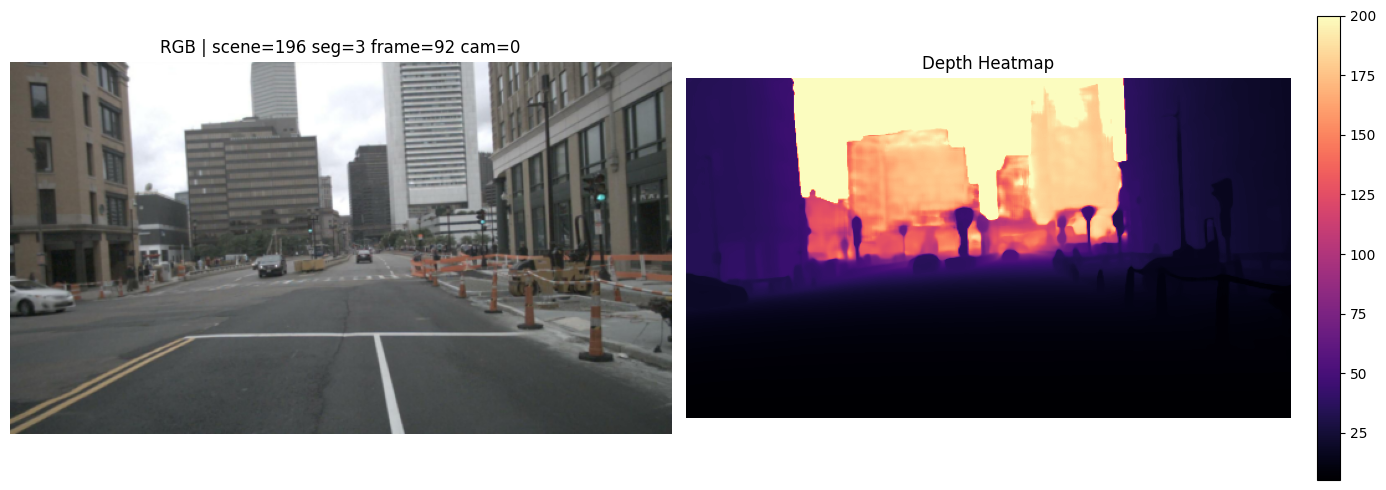

In [8]:
# 1) 指定 scene / segment / frame / camera，读取图像 + 深度热力图
req = BatchRequestV4(
    scene_id=int(scene_id),
    segment_id=int(segment_id),
    source_image_ref=(int(frame_idx), int(camera_id)),
    source_image_refs=[(int(frame_idx), int(camera_id))],
    target_image_refs=[(int(frame_idx), int(camera_id))],
    include_test=False,
)

batch = dataset.get_segment_batch_from_image_refs(req, enforce_target0_equals_source=True)

img = batch["source"]["image"][0].detach().cpu().numpy()  # [H,W,3], float32 in [0,1]
depth = batch["source"]["depth"][0].detach().cpu().numpy()  # [H,W], float32

vmin = float(np.nanpercentile(depth, 1.0))
vmax = float(np.nanpercentile(depth, 99.0))
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
    raise ValueError(f"invalid depth range: vmin={vmin}, vmax={vmax}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.clip(img, 0.0, 1.0))
axes[0].set_title(f"RGB | scene={scene_id} seg={segment_id} frame={frame_idx} cam={camera_id}")
axes[0].axis("off")

im = axes[1].imshow(depth, cmap="magma", vmin=vmin, vmax=vmax)
axes[1].set_title("Depth Heatmap")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
# 2) BG RGB 点云可视化
#    与 MultiSceneDataset_Demo 一致：默认用 PLYViewer（Web 点云），避免 nerfview 后台线程里跑 gsplat 导致 kernel 崩。
#    需要「小高斯 + 实时 raster、界面像 nerfview」时，把下面改成 "nerfview"。

bg_pointcloud_backend = "plyviewer"  # "plyviewer" | "nerfview"

bundle = dataset._resolve_segment_bundle(int(scene_id), int(segment_id))
bg_np = np.asarray(bundle.pointcloud.get("background", np.zeros((0, 6), dtype=np.float32)), dtype=np.float32)
if bg_np.ndim != 2 or bg_np.shape[1] < 3 or bg_np.shape[0] == 0:
    raise ValueError(f"Invalid background pointcloud shape: {bg_np.shape}")

bg_xyz = bg_np[:, :3]
if bg_np.shape[1] >= 6:
    raw_c = bg_np[:, 3:6].astype(np.float32)
    # 与 MultiSceneDataset 中 PLY 导出一致：多数资产为 0–255，误当作 0–1 clip 会得到全白点
    _cmax = float(np.nanmax(raw_c)) if raw_c.size else 0.0
    if _cmax > 1.5:
        bg_rgb = np.clip(raw_c / 255.0, 0.0, 1.0)
    else:
        bg_rgb = np.clip(raw_c, 0.0, 1.0)
else:
    bg_rgb = np.full((bg_xyz.shape[0], 3), 0.7, dtype=np.float32)

# 下采样防止太慢（笔记本里 worker 线程 + gsplat 过大易触发不稳定）
max_bg_points = 120000
if bg_xyz.shape[0] > max_bg_points:
    rng = np.random.default_rng(42)
    keep = np.sort(rng.choice(bg_xyz.shape[0], size=max_bg_points, replace=False))
    bg_xyz = bg_xyz[keep]
    bg_rgb = bg_rgb[keep]

# 重跑本 cell 时先关掉之前的 viewer，避免占端口
if "_bg_server" in globals() and _bg_server is not None:
    try:
        _bg_server.stop()
    except Exception:
        pass
_bg_server = None
_bg_viewer = None
if "_bg_ply_viewer" in globals() and _bg_ply_viewer is not None:
    try:
        _bg_ply_viewer.stop()
    except Exception:
        pass

if bg_pointcloud_backend == "plyviewer":
    from tools.plyviewer import PLYViewer

    bg_colors_u8 = np.clip(np.round(bg_rgb * 255.0), 0, 255).astype(np.uint8)
    _bg_ply_viewer = PLYViewer(
        host=viewer_host,
        port=int(bg_viewer_port),
        point_size=1,
        point_shape="circle",
        auto_fallback=True,
    )
    _bg_ply_viewer.start_viewer()
    _bg_ply_viewer.viser_server.gui.configure_theme(dark_mode=False, control_layout="collapsible")
    # 3D 画布白色背景（否则默认接近黑）
    _bg_ply_viewer.viser_server.scene.set_background_image(
        np.full((256, 256, 3), 255, dtype=np.uint8),
        format="jpeg",
        jpeg_quality=95,
    )
    _bg_ply_viewer.add_point_cloud(
        points=bg_xyz.astype(np.float32),
        colors=bg_colors_u8,
        name="/background",
        visible=True,
    )
    print("\n", _bg_ply_viewer.viewer_info)
    print(
        "BG point cloud viewer (PLYViewer, same pattern as MultiSceneDataset_Demo): "
        f"http://localhost:{int(_bg_ply_viewer.port)}"
    )
else:
    _bg_ply_viewer = None

    means_bg = torch.from_numpy(bg_xyz).float().to(device)
    colors_bg = torch.from_numpy(bg_rgb).float().to(device)

    # 单位四元数 + 小尺度
    quats_bg = torch.zeros((means_bg.shape[0], 4), dtype=torch.float32, device=device)
    quats_bg[:, 0] = 1.0
    scales_bg = torch.full((means_bg.shape[0], 3), 0.03, dtype=torch.float32, device=device)
    opacities_bg = torch.full((means_bg.shape[0],), 0.75, dtype=torch.float32, device=device)

    @torch.no_grad()
    def render_bg_pointcloud_white(camera_state: nerfview.CameraState, img_wh):
        """Must not raise: nerfview's render thread calls os._exit(1) on any Exception."""
        import traceback

        w, h = _nerfview_img_wh(img_wh)
        fallback = np.full((h, w, 3), 128, dtype=np.uint8)
        try:
            with torch.cuda.device(device):
                c2w = torch.from_numpy(camera_state.c2w).float().to(device)
                K = torch.from_numpy(camera_state.get_K((w, h))).float().to(device)

                render_colors, _, _ = rasterization(
                    means=means_bg,
                    quats=quats_bg,
                    scales=scales_bg,
                    opacities=opacities_bg,
                    colors=colors_bg,
                    viewmats=torch.linalg.inv(c2w)[None, ...],
                    Ks=K[None, ...],
                    width=int(w),
                    height=int(h),
                    packed=False,
                    backgrounds=torch.ones((1, 3), dtype=torch.float32, device=device),
                    rasterize_mode="antialiased",
                )
            rgb = torch.clamp(render_colors[0], 0.0, 1.0).cpu().numpy()
            return (rgb * 255.0).astype(np.uint8)
        except Exception:
            traceback.print_exc()
            return fallback

    _bg_server = viser.ViserServer(host=viewer_host, port=int(bg_viewer_port), verbose=False)
    _bg_viewer = nerfview.Viewer(
        server=_bg_server,
        render_fn=render_bg_pointcloud_white,
        mode="rendering",
    )
    _bg_viewer.render_tab_state.viewer_res = 512

    print(f"BG pointcloud viewer (nerfview+gsplat): http://localhost:{bg_viewer_port}")
    print("White background: enabled")

[12:36:04] Viewer stopped                                                                          ]8;id=518676;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=378179;file:///root/drivestudio-coding/tools/plyviewer.py#496\496]8;;\

           Port 8099 is already in use. Attempting to free the port (only viewer processes)...     ]8;id=435454;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=249116;file:///root/drivestudio-coding/tools/plyviewer.py#264\264]8;;\

           Could not check processes on port 8099: [Errno 2] No such file or directory: 'lsof'     ]8;id=424116;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=626993;file:///root/drivestudio-coding/tools/plyviewer.py#247\247]8;;\

           Could not free port 8099 (may be used by other processes). Automatically finding an     ]8;id=103779;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=970984;file:///root/drivestudio-coding/tools/plyviewer.py#279\279]8;;\
           available port...                                                                                       

           Using port 49733 instead. Access viewer at: http://localhost:49733                      ]8;id=638033;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=208260;file:///root/drivestudio-coding/tools/plyviewer.py#284\284]8;;\

...

             Total point clouds in viewer: 1                                                       ]8;id=563775;file:///root/drivestudio-coding/tools/plyviewer.py\plyviewer.py]8;;\:]8;id=889202;file:///root/drivestudio-coding/tools/plyviewer.py#440\440]8;;\


 Viewer running locally at: http://localhost:49733 (listening on 0.0.0.0)
BG point cloud viewer (PLYViewer, same pattern as MultiSceneDataset_Demo): http://localhost:49733


I20260508 12:36:16 websockets.server server.py:529] connection open


(viser) Connection opened (0, 1 total), 8 persistent messages

(viser) Connection closed (0, 0 total)

In [ ]:
# 3) 按 stage5_4 配置初始化 3DGS 场景，并用 nerfview 演示（白色背景）

# 选择 trainer
use_production = bool((cfg.get("model") or {}).get("production_training", False))
trainer_cls = MinimalStreetForwardStage5_4_Production if use_production else MinimalStreetForwardStage5_4

trainer = trainer_cls(config=cfg, device=device).to(device)
for p in trainer.parameters():
    p.requires_grad_(False)
trainer.eval()

scheduler = build_stage5_demo_scheduler_from_cfg(cfg, dataset)
controller = Stage5DemoController(
    cfg=cfg,
    dataset=dataset,
    scheduler=scheduler,
    trainer=trainer,
    device=device,
    stage="5_4",
)

# prime 后再 step 一次，让 node states 初始化
controller.prime()
controller.step_once()

@torch.no_grad()
def render_stage5_white_bg(
    camera_state: nerfview.CameraState,
    img_wh,
    *,
    show_bg=True,
    show_distant=True,
    show_rigid=False,
    rigid_frame_idx=None,
):
    w, h = _nerfview_img_wh(img_wh)

    scene_cur = int(controller.display.last_stats.get("scene_id", scene_id))
    seg_cur = int(controller.display.last_stats.get("segment_id", segment_id))
    key = (scene_cur, seg_cur)

    node_state_bg = trainer.node_states_bg.get(key)
    node_state_distant = trainer.node_states_distant.get(key)
    node_state_rigid = getattr(trainer, "node_states_rigid", {}).get(key)

    means_list = []
    scales_list = []
    quats_list = []
    opacities_list = []
    colors_list = []

    if show_bg and node_state_bg is not None and int(node_state_bg.means.shape[0]) > 0:
        means_list.append(node_state_bg.means)
        scales_list.append(torch.exp(node_state_bg.scales_log))
        quats_list.append(node_state_bg.quats)
        opacities_list.append(torch.sigmoid(node_state_bg.opacity_logit).squeeze(-1))
        colors_list.append(torch.cat([node_state_bg.sh_dc[:, None, :], node_state_bg.sh_rest], dim=1))

    if show_distant and node_state_distant is not None and int(node_state_distant.means.shape[0]) > 0:
        means_list.append(node_state_distant.means)
        scales_list.append(torch.exp(node_state_distant.scales_log))
        quats_list.append(node_state_distant.quats)
        opacities_list.append(torch.sigmoid(node_state_distant.opacity_logit).squeeze(-1))
        colors_list.append(torch.cat([node_state_distant.sh_dc[:, None, :], node_state_distant.sh_rest], dim=1))

    if show_rigid and node_state_rigid is not None and int(node_state_rigid.means.shape[0]) > 0:
        render_rigid_frame = int(rigid_frame_idx) if rigid_frame_idx is not None else int(controller.display.last_stats.get("source_frame_idx", -1))
        if render_rigid_frame >= 0 and hasattr(trainer, "_rigid_point_valid_mask") and hasattr(trainer, "_route_rigid_source_points"):
            mask_src_rigid = trainer._rigid_point_valid_mask(node_state_rigid, int(render_rigid_frame))
            if isinstance(mask_src_rigid, torch.Tensor):
                S = torch.nonzero(mask_src_rigid, as_tuple=False).squeeze(1)
                if int(S.numel()) > 0:
                    route = trainer._route_rigid_source_points(node_state_rigid, int(render_rigid_frame), S)
                    means_list.append(route.means_world_S)
                    quats_list.append(route.quats_world_S)
                    scales_list.append(torch.exp(node_state_rigid.scales_log[S]))
                    opacities_list.append(torch.sigmoid(node_state_rigid.opacity_logit[S]).squeeze(-1))
                    colors_list.append(torch.cat([node_state_rigid.sh_dc[S, None, :], node_state_rigid.sh_rest[S]], dim=1))

    if len(means_list) == 0:
        return np.full((int(h), int(w), 3), 255, dtype=np.uint8)

    import traceback

    try:
        with torch.cuda.device(device):
            means = torch.cat(means_list, dim=0)
            scales = torch.cat(scales_list, dim=0)
            quats = torch.cat(quats_list, dim=0)
            opacities = torch.cat(opacities_list, dim=0)
            colors = torch.cat(colors_list, dim=0)

            c2w = torch.from_numpy(camera_state.c2w).float().to(device)
            if controller.align_gaussians_to_nerfview:
                if controller.coord_align_mode == "gaussian":
                    means = controller._to_nerfview_world_means(means)
                    quats = controller._to_nerfview_world_quats(quats)
                elif controller.coord_align_mode == "camera":
                    c2w = controller._nerfview_camera_c2w_to_dataset_c2w(c2w)

            K = torch.from_numpy(camera_state.get_K((w, h))).float().to(device)
            sh_degree = controller._infer_sh_degree(colors)

            render_colors, _, _ = rasterization(
                means=means,
                quats=quats,
                scales=scales,
                opacities=opacities,
                colors=colors,
                viewmats=torch.linalg.inv(c2w)[None, ...],
                Ks=K[None, ...],
                width=int(w),
                height=int(h),
                sh_degree=sh_degree,
                packed=False,
                backgrounds=torch.ones((1, 3), dtype=torch.float32, device=device),
                rasterize_mode="antialiased",
            )
        rgb = torch.clamp(render_colors[0], 0.0, 1.0).detach().cpu().numpy()
        return (rgb * 255.0).astype(np.uint8)
    except Exception:
        traceback.print_exc()
        return np.full((int(h), int(w), 3), 255, dtype=np.uint8)

class WhiteBGStage5Viewer(StreetForwardStage5Viewer):
    def _render_from_state(self, camera_state, img_wh):
        if not self._demo_tab_handles:
            w, h = _nerfview_img_wh(img_wh)
            return np.full((int(h), int(w), 3), 255, dtype=np.uint8)
        show_bg = bool(self._demo_tab_handles["show_bg"].value)
        show_distant = bool(self._demo_tab_handles["show_distant"].value)
        show_rigid = bool(self._demo_tab_handles["show_rigid"].value)
        rigid_frame_value = int(self._demo_tab_handles["rigid_frame"].value)
        rigid_frame_idx = rigid_frame_value if rigid_frame_value >= 0 else None
        return render_stage5_white_bg(
            camera_state,
            img_wh,
            show_bg=show_bg,
            show_distant=show_distant,
            show_rigid=show_rigid,
            rigid_frame_idx=rigid_frame_idx,
        )

if "_stage5_server" in globals() and _stage5_server is not None:
    try:
        _stage5_server.stop()
    except Exception:
        pass

_stage5_server = viser.ViserServer(host=viewer_host, port=int(stage5_viewer_port), verbose=False)
_stage5_viewer = WhiteBGStage5Viewer(
    server=_stage5_server,
    controller=controller,
    output_dir=Path(cfg.log_dir) / "stage5_demo_viewer_white_bg",
)

print(f"Stage5_4 3DGS viewer: http://localhost:{stage5_viewer_port}")
print("White background: enabled")

I20260508 12:29:37 timm.models._builder _builder.py:217] Loading pretrained weights from Hugging Face hub (timm/vit_base_patch14_reg4_dinov2.lvd142m)
I20260508 12:29:37 timm.models._hub _hub.py:233] [timm/vit_base_patch14_reg4_dinov2.lvd142m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
I20260508 12:29:37 models.streetforward.minimal_trainer_stage5_3_production minimal_trainer_stage5_3_production.py:212] optimizer/group/default/num_params=76
I20260508 12:29:37 models.streetforward.minimal_trainer_stage5_3_production minimal_trainer_stage5_3_production.py:212] optimizer/group/residual_unet/num_params=54
I20260508 12:29:37 models.streetforward.minimal_trainer_stage5_3_production minimal_trainer_stage5_3_production.py:212] optimizer/group/fusion_neck/num_params=8
I20260508 12:29:37 models.streetforward.minimal_trainer_stage5_3_production minimal_trainer_stage5_3_production.py:212] optimizer/group/struct_near_xcpe/num_param

╭────── viser (listening *:8100) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8100   │
│   Websocket │ ws://localhost:8100     │
│             ╵                         │
╰───────────────────────────────────────╯

Stage5_4 3DGS viewer: http://localhost:8100
White background: enabled


(viser) Connection opened (0, 1 total), 7 persistent messages

(viser) Connection closed (0, 0 total)

(viser) Connection opened (1, 1 total), 7 persistent messages

(viser) Connection closed (1, 0 total)

## 使用说明

- 按顺序运行 Cell 1 -> 5。
- 先根据你的资产实际情况修改 `scene_id / segment_id / frame_idx / camera_id`。
- 第 2 部分运行后看终端打印的 URL（默认 `PLYViewer` 与 Demo 一致；若端口占用可能自动换端口）。
- 第 3 部分打开 `http://localhost:8100`。
- 若端口冲突，改 `bg_viewer_port` 和 `stage5_viewer_port`。